# Generated-paper length and model analysis

This notebook analyzes research papers generated by Ollama models and one HuggingFace model (apertus)

## Setup

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True


## Choose the generated-paper directory

In [2]:
# Change this path depending on where you have your assembled papers
DATA_DIR = Path("assembled_papers_iter2")

if not DATA_DIR.exists():
    print(f"Directory not found: {DATA_DIR.resolve()}")
    print("Update DATA_DIR to point to your assembled_papers_milouche directory.")
else:
    print(f"Using directory: {DATA_DIR.resolve()}")


Using directory: /Users/verce/Desktop/Science des donnes-semsetre 6/Final Project/assembled_papers_iter2


## Helper functions

In [3]:
WORD_RE = re.compile(r"\b[a-zA-Z]+(?:[-'][a-zA-Z]+)*\b")

PREFERRED_SECTION_ORDER = [
    "introduction",
    "related_work",
    "background",
    "method",
    "methods",
    "approach",
    "experiments",
    "results",
    "discussion",
    "conclusion",
]

def normalize_text(text: str) -> str:
    if text is None:
        return ""
    text = text.replace("\x00", " ")
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def clean_generated_text(text: str) -> str:
    text = normalize_text(text)

    # Remove simple markdown headings such as "#", "##", etc.
    text = re.sub(r"(?m)^\s{0,3}#{1,6}\s+", "", text)

    # Remove repeated separator-like lines
    text = re.sub(r"(?m)^\s*[-_=]{3,}\s*$", "", text)

    return normalize_text(text)

def count_words(text: str) -> int:
    text = clean_generated_text(text)
    return len(WORD_RE.findall(text))

def find_json_files(data_dir: Path):
    return sorted(
        list(data_dir.rglob("*.json")) + list(data_dir.rglob("*.jsonl"))
    )

def read_records_from_path(path: Path):
    if path.suffix.lower() == ".jsonl":
        records = []
        with path.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                if isinstance(obj, dict):
                    records.append(obj)
        return records

    with path.open("r", encoding="utf-8") as f:
        obj = json.load(f)

    if isinstance(obj, dict):
        return [obj]
    if isinstance(obj, list):
        return [x for x in obj if isinstance(x, dict)]
    return []

def order_sections(sections: dict, available_sections=None):
    if not isinstance(sections, dict):
        return []

    used = set()
    ordered = []

    if isinstance(available_sections, list):
        for name in available_sections:
            if name in sections:
                ordered.append((name, sections[name]))
                used.add(name)

    for name in PREFERRED_SECTION_ORDER:
        if name in sections and name not in used:
            ordered.append((name, sections[name]))
            used.add(name)

    for name in sections:
        if name not in used:
            ordered.append((name, sections[name]))
            used.add(name)

    return ordered

def build_paper_text(record: dict):
    title = clean_generated_text(record.get("selected_title", ""))
    abstract = clean_generated_text(record.get("abstract", ""))
    sections = record.get("sections", {}) or {}
    available_sections = record.get("available_sections", None)

    ordered_sections = order_sections(sections, available_sections)
    section_texts = [clean_generated_text(text) for _, text in ordered_sections]

    body_text = "\n\n".join([t for t in section_texts if t])
    full_text = "\n\n".join([x for x in [title, abstract, body_text] if x])

    return title, abstract, body_text, full_text, ordered_sections

def record_to_row(record: dict, source_file: str):
    title, abstract, body_text, full_text, ordered_sections = build_paper_text(record)

    row = {
        "source_file": source_file,
        "idea_id": record.get("idea_id"),
        "model": record.get("model") or record.get("generation_model"),
        "topic": record.get("topic"),
        "chosen_direction": record.get("chosen_direction"),
        "refined_problem": record.get("refined_problem"),
        "selected_title": record.get("selected_title"),
        "abstract": abstract,
        "body_text": body_text,
        "full_text": full_text,
        "n_sections_present": len(ordered_sections),
        "available_sections_declared": len(record.get("available_sections", []) or []),
        "missing_sections_declared": len(record.get("missing_sections", []) or []),
        "abstract_word_count": count_words(abstract),
        "body_word_count": count_words(body_text),
        "full_word_count": count_words(full_text),
    }

    for section_name, section_text in ordered_sections:
        safe_name = re.sub(r"[^a-zA-Z0-9_]+", "_", section_name.strip().lower()).strip("_")
        row[f"section__{safe_name}"] = clean_generated_text(section_text)
        row[f"section_words__{safe_name}"] = count_words(section_text)

    return row


## Load generated papers

In [4]:
if DATA_DIR.exists():
    files = find_json_files(DATA_DIR)
    print(f"Found {len(files):,} JSON/JSONL files.")

    rows = []
    for path in files:
        try:
            records = read_records_from_path(path)
            for record in records:
                rows.append(record_to_row(record, str(path.relative_to(DATA_DIR))))
        except Exception as e:
            print(f"Skipping {path.name}: {e}")

    df_gen = pd.DataFrame(rows)
    print(f"Loaded {len(df_gen):,} generated papers.")
    display(df_gen.head(3))
else:
    df_gen = pd.DataFrame()


Found 280 JSON/JSONL files.
Loaded 280 generated papers.


,source_file,idea_id,model,topic,chosen_direction,refined_problem,selected_title,abstract,body_text,full_text,...,section__related_work,section_words__related_work,section__background,section_words__background,section__method,section_words__method,section__experiments,section_words__experiments,section__conclusion,section_words__conclusion
0,hf_swiss-ai_Apertus-8B-Instruct-2509/idea_001_...,idea_001_04,hf:swiss-ai/Apertus-8B-Instruct-2509,adversarial attacks on vision transformers,theoretical issues in deep learning,Analyzing the theoretical vulnerability of vis...,Comparing Adversarial Robustness of Vision Tra...,Recent advances in vision transformers (ViTs) ...,Neural network-based models have become ubiqui...,Comparing Adversarial Robustness of Vision Tra...,...,Related Work\n1. Adversarial Perturbations and...,784,Background\n\nThe advent of vision transformer...,495,**Method**\n\nWe introduce a systematic framew...,603,Experiments\n\nThe purpose of the experiments ...,706,**Conclusion**\n\nThe last decade has seen tre...,676
1,hf_swiss-ai_Apertus-8B-Instruct-2509/idea_002_...,idea_002_06,hf:swiss-ai/Apertus-8B-Instruct-2509,continual learning for lifelong adaptation,representation learning for planning and reinf...,Designing continual learning algorithms that m...,Optimization-Based Continual Learning: Enhanci...,Continual learning aims to enable models to ad...,Continual learning (CL) is an area of active r...,Optimization-Based Continual Learning: Enhanci...,...,Related Work\n\nContinual learning (Thrun & Mi...,738,Background\n\nContinual learning (CL) is an es...,507,Method\n\nContinual learning algorithms face t...,611,Experiments\n\nThe evaluation of GPR is conduc...,819,"**Conclusion**\n\nContinual learning, a critic...",530
2,hf_swiss-ai_Apertus-8B-Instruct-2509/idea_002_...,idea_002_07,hf:swiss-ai/Apertus-8B-Instruct-2509,continual learning for lifelong adaptation,representation learning for planning and reinf...,Designing continual learning algorithms that m...,Evaluating Continual Representation Learning A...,Continual learning aims to enable models to ad...,"Continual learning, also known as lifelong lea...",Evaluating Continual Representation Learning A...,...,Related Work\n\nContinual learning is a long-s...,620,Background\n\nContinual learning (CL) refers t...,660,**Method**\n\nContinual learning aims to enabl...,752,Experiments\n\nThe primary goal of our experim...,928,"In conclusion, this study investigates the pro...",448


In [5]:
MAX_WORDS = 50_000

degenerate = df_gen[df_gen["full_word_count"] > MAX_WORDS]
print(f"Excluding {len(degenerate)} degenerate paper(s):")
display(degenerate[["model", "idea_id", "full_word_count"]])

df_gen = df_gen[df_gen["full_word_count"] <= MAX_WORDS].reset_index(drop=True)
print(f"{len(df_gen):,} papers retained.")

Excluding 0 degenerate paper(s):


,model,idea_id,full_word_count


280 papers retained.


## Basic validation

In [6]:
coverage = pd.DataFrame({
    "metric": [
        "generated_papers",
        "models",
        "papers_with_abstract",
        "papers_with_body_text",
        "papers_with_topic",
    ],
    "value": [
        len(df_gen),
        df_gen["model"].nunique(dropna=True),
        df_gen["abstract"].astype(bool).sum(),
        df_gen["body_text"].astype(bool).sum(),
        df_gen["topic"].notna().sum(),
    ],
})

display(coverage)

papers_per_model = (
    df_gen["model"]
    .value_counts(dropna=False)
    .rename_axis("model")
    .reset_index(name="n_papers")
)

display(papers_per_model)

,metric,value
0,generated_papers,280
1,models,7
2,papers_with_abstract,280
3,papers_with_body_text,280
4,papers_with_topic,280


,model,n_papers
0,hf:swiss-ai/Apertus-8B-Instruct-2509,40
1,llama3.1:8b,40
2,phi4-reasoning:14b,40
3,qwen2.5:7b,40
4,qwen3:14b,40
5,qwen3.5:9b,40
6,qwen3:8b,40


## Summary statistics of paper length by model


In [7]:
if len(df_gen) > 0:
    summary_by_model = (
        df_gen.groupby("model")["full_word_count"]
        .agg(["count", "mean", "median", "min", "max", "std"])
        .sort_values("count", ascending=False)
    )
    display(summary_by_model)

    overall_summary = df_gen["full_word_count"].agg(["count", "mean", "median", "min", "max", "std"])
    display(overall_summary.to_frame("overall"))


,count,mean,median,min,max,std
model,,,,,,
hf:swiss-ai/Apertus-8B-Instruct-2509,40,3993.825,3999.0,3335,5006,357.342319
llama3.1:8b,40,3066.425,3034.5,2689,3519,177.700539
phi4-reasoning:14b,40,11589.525,11518.5,9705,13515,953.922885
qwen2.5:7b,40,2788.750,2766.5,2484,3153,146.061411
qwen3.5:9b,40,6256.525,6261.5,5743,6826,240.476129
qwen3:14b,40,5947.000,5908.5,5523,6549,253.095806
qwen3:8b,40,6905.775,6885.5,6052,7932,332.892490


,overall
count,280.000000
mean,5792.546429
median,5863.000000
min,2484.000000
max,13515.000000
std,2835.097383


## Inspect the longest and shortest generated papers

In [8]:
if len(df_gen) > 0:
    display(df_gen.nlargest(5, "full_word_count")[[
        "model", "idea_id", "topic", "selected_title", "full_word_count"
    ]])

    display(df_gen.nsmallest(5, "full_word_count")[[
        "model", "idea_id", "topic", "selected_title", "full_word_count"
    ]])


,model,idea_id,topic,selected_title,full_word_count
102,phi4-reasoning:14b,idea_022_01,stochastic gradient descent with variance redu...,Variance-Reduced Stochastic Gradient Descent f...,13515
94,phi4-reasoning:14b,idea_014_02,sequential learning with recurrent networks,Optimizing State Representations for Dual Obje...,13426
105,phi4-reasoning:14b,idea_024_02,exploration strategies in reinforcement learning,Hierarchical Representation Learning for Goal-...,13181
93,phi4-reasoning:14b,idea_013_07,Atari game playing with reinforcement learning,Learning to Plan with Learned Representations:...,13092
95,phi4-reasoning:14b,idea_014_03,sequential learning with recurrent networks,Theoretical Analysis of Jointly Predictive and...,12811


,model,idea_id,topic,selected_title,full_word_count
125,qwen2.5:7b,idea_006_03,feature selection in deep learning,A Theoretical Analysis of Sparse Coding in Dee...,2484
145,qwen2.5:7b,idea_029_03,video prediction with recurrent networks,Disentangled Temporal Representations in Hiera...,2560
129,qwen2.5:7b,idea_010_03,active learning for data efficiency,Meta-Learning Acquisition Functions for Active...,2609
132,qwen2.5:7b,idea_013_01,Atari game playing with reinforcement learning,Learning Hierarchical Representations for Long...,2615
146,qwen2.5:7b,idea_029_05,video prediction with recurrent networks,Multi-Granularity Temporal Encoding in Hierarc...,2621


## Paper length distribution per model

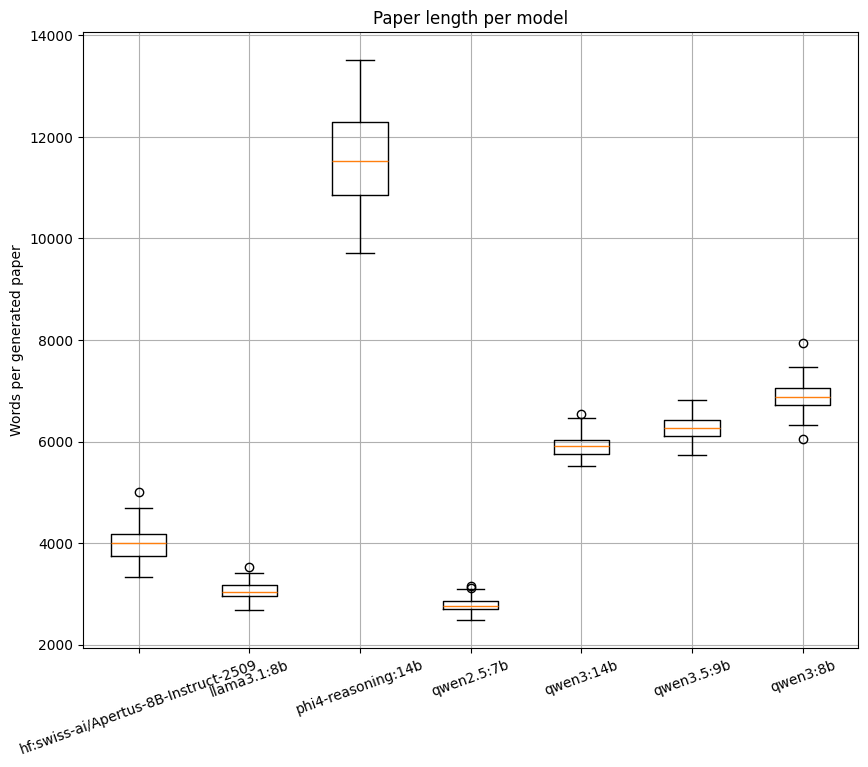

In [9]:
if len(df_gen) > 0:
    df_plot = df_gen[df_gen["full_word_count"] <= 15000]

    ordered_models = (
        df_plot["model"]
        .value_counts()
        .index
        .tolist()
    )

    data = [df_plot.loc[df_plot["model"] == model_name, "full_word_count"].dropna().to_numpy()
        for model_name in ordered_models
    ]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.boxplot(data, tick_labels=ordered_models)
    ax.set_title("Paper length per model")
    ax.set_ylabel("Words per generated paper")
    plt.xticks(rotation=20)
    plt.show()

# Sentence inspaction

* Sentence segmentation is regex-based and approximate

In [10]:
SENTENCE_SPLIT_RE = re.compile(r'[.!?]+(?:\s+|$)')

def split_sentences(text):
    if not isinstance(text, str):
        return []
    return [s.strip() for s in SENTENCE_SPLIT_RE.split(text) if s.strip()]

def compute_sentence_stats(text):
    lengths = [len(s.split()) for s in split_sentences(text)]
    if not lengths:
        return {"sentence_count": 0, "mean_sentence_length": 0,
                "median_sentence_length": 0, "std_sentence_length": 0,
                "max_sentence_length": 0}
    return {
        "sentence_count": len(lengths),
        "mean_sentence_length": np.mean(lengths),
        "median_sentence_length": np.median(lengths),
        "std_sentence_length": np.std(lengths),
        "max_sentence_length": np.max(lengths),
    }

# sentence stats on the full paper text (this is what Flesch / coherence / the ICLR
# comparison actually use)
full_stats = (df_gen["full_text"].apply(compute_sentence_stats)
              .apply(pd.Series).add_prefix("full_"))
df_sentence = pd.concat([df_gen, full_stats], axis=1)

# --- summary table: sentence length by model ---
sentence_summary = (
    df_sentence.groupby("model")
    .agg(
        n_papers=("model", "size"),
        mean_sentence_length=("full_mean_sentence_length", "mean"),
        median_sentence_length=("full_median_sentence_length", "mean"),
        std_sentence_length=("full_std_sentence_length", "mean"),
        mean_sentence_count=("full_sentence_count", "mean"),
    )
    .round(2)
    .sort_values("mean_sentence_length")
)
display(sentence_summary)

,n_papers,mean_sentence_length,median_sentence_length,std_sentence_length,mean_sentence_count
model,,,,,
phi4-reasoning:14b,40,20.56,20.26,9.65,569.10
hf:swiss-ai/Apertus-8B-Instruct-2509,40,21.09,21.74,9.22,193.12
qwen2.5:7b,40,22.13,22.15,7.55,127.78
llama3.1:8b,40,22.76,22.30,8.36,136.98
qwen3.5:9b,40,23.36,22.96,6.25,268.23
qwen3:8b,40,24.97,24.74,6.25,276.25
qwen3:14b,40,26.41,26.18,6.84,224.88


## Lexical diversity and repetition 


In [11]:
def ttr(text, cap=2000):
    w = WORD_RE.findall(text.lower()) if isinstance(text, str) else []
    w = w[:cap]
    return len(set(w)) / len(w) if w else np.nan

def rep_ngram(text, n=3):
    w = WORD_RE.findall(text.lower()) if isinstance(text, str) else []
    if len(w) < n + 1:
        return np.nan
    g = [tuple(w[i:i+n]) for i in range(len(w) - n + 1)]
    return 1 - len(set(g)) / len(g)

df_gen["ttr"]  = df_gen["full_text"].apply(ttr)
df_gen["rep3"] = df_gen["full_text"].apply(rep_ngram)

display(df_gen.groupby("model")[["ttr", "rep3"]].agg(["mean", "median"]).round(3))

ttr          rep3       
                                       mean median   mean median
model                                                           
hf:swiss-ai/Apertus-8B-Instruct-2509  0.223  0.226  0.301  0.300
llama3.1:8b                           0.225  0.224  0.324  0.326
phi4-reasoning:14b                    0.282  0.281  0.229  0.229
qwen2.5:7b                            0.257  0.256  0.208  0.210
qwen3.5:9b                            0.309  0.307  0.182  0.181
qwen3:14b                             0.282  0.281  0.207  0.208
qwen3:8b                              0.274  0.269  0.251  0.251

## Citation check


In [12]:
CITE_RE = re.compile(r"\[\d{1,3}(?:\s*[,-]\s*\d{1,3})*\]"
                     r"|\([A-Z][A-Za-z]+(?: et al\.?)?,?\s+\d{4}[a-z]?\)")

df_gen["n_citations"] = df_gen["full_text"].apply(
    lambda t: len(CITE_RE.findall(t)) if isinstance(t, str) else 0)
df_gen["has_citations"] = df_gen["n_citations"] > 0

display(df_gen.groupby("model")
        .agg(mean_citations=("n_citations", "mean"),
             median_citations=("n_citations", "median"),
             pct_with_citations=("has_citations", "mean"))
        .round(2).sort_values("mean_citations", ascending=False))


,mean_citations,median_citations,pct_with_citations
model,,,
hf:swiss-ai/Apertus-8B-Instruct-2509,6.48,5.5,0.95
qwen3:8b,3.92,3.0,0.65
llama3.1:8b,3.82,3.0,0.78
qwen2.5:7b,3.62,3.0,0.82
qwen3:14b,1.27,0.0,0.35
phi4-reasoning:14b,0.92,0.0,0.38
qwen3.5:9b,0.00,0.0,0.00


### Extracted individual citation (for manual inspection)

In [13]:
def extract_citation_contexts(text, pattern=CITE_RE, window=80):
    contexts = []
    if not isinstance(text, str):
        return contexts
    for m in pattern.finditer(text):
        start, end = m.span()
        left = text[max(0, start - window):start].replace("\n", " ")
        right = text[end:end + window].replace("\n", " ")
        contexts.append({
            "citation": m.group(0),
            "context": f"...{left.strip()} >>>{m.group(0)}<<< {right.strip()}...",
        })
    return contexts

citation_rows = []
for _, row in df_gen.iterrows():
    for c in extract_citation_contexts(row["full_text"]):
        citation_rows.append({
            "source_file": row["source_file"],
            "model": row["model"],
            "selected_title": row["selected_title"],
            "citation": c["citation"],
            "context": c["context"],
        })

df_citations = pd.DataFrame(citation_rows)
print(f"Extracted {len(df_citations):,} citation instances "
      f"from {df_citations['source_file'].nunique() if len(df_citations) else 0} papers.")

citation_counts = (
    df_citations["citation"].value_counts()
    .rename_axis("citation")
    .reset_index(name="n_occurrences")
)
display(citation_counts.head(30))

sample_citations = df_citations.sample(n=min(20, len(df_citations)), random_state=42) if len(df_citations) else df_citations
display(sample_citations)

df_citations.to_csv("extracted_citations_for_review.csv", index=False)



Extracted 802 citation instances from 157 papers.


,citation,n_occurrences
0,[1],20
1,"(Zhu et al., 2017)",18
2,[2],17
3,"(Chen et al., 2020)",16
4,[3],14
5,[4],12
6,"(Snell et al., 2017)",12
7,"(Isola et al., 2017)",12
8,"(Mnih et al., 2015)",11
9,[5],9


,source_file,model,selected_title,citation,context
192,hf_swiss-ai_Apertus-8B-Instruct-2509/idea_021_...,hf:swiss-ai/Apertus-8B-Instruct-2509,A Hierarchical VAE with Explicit Metric Constr...,"(Kumar et al., 2014)",...bility assesses the robustness of cluster a...
294,llama3_1_8b/idea_011_04.json,llama3.1:8b,A Theoretical Framework for Scalable Variation...,[3],...of the VAE that incorporates structured spa...
168,hf_swiss-ai_Apertus-8B-Instruct-2509/idea_017_...,hf:swiss-ai/Apertus-8B-Instruct-2509,Semi-Supervised Prototype Refinement via Contr...,"(Sung et al., 2018)","...c (e.g., cosine similarity) to classify nov..."
521,qwen2_5_7b/idea_019_07.json,qwen2.5:7b,Theoretical Insights into Adversarial Training...,"(Dai et al., 2017)",...iscriminator learn decision boundaries in l...
535,qwen2_5_7b/idea_029_03.json,qwen2.5:7b,Disentangled Temporal Representations in Hiera...,"(Wang et al., 2018)","...gled latent variables. For example, PredNet..."
788,qwen3_8b/idea_032_05.json,qwen3:8b,Metric Regularization in GANs: Bridging the Ga...,"(Chen et al., 2019)",...to capture fine-grained structural relation...
591,qwen2_5_7b/idea_039_04.json,qwen2.5:7b,Metric Learning in Knowledge Distillation: Bri...,"(Xing et al., 2003)",...ing has emerged as a technique to learn a d...
323,llama3_1_8b/idea_020_01.json,llama3.1:8b,Adaptive Loss Weighting in Semi-Supervised CNN...,"(Dong et al., 2015)","..., unsupervised learning approaches, such as..."
218,hf_swiss-ai_Apertus-8B-Instruct-2509/idea_031_...,hf:swiss-ai/Apertus-8B-Instruct-2509,A Theoretical Framework for Evaluating the Ind...,"(Solway et al., 2014)","...ect generalization. Similarly, the hierarch..."
405,llama3_1_8b/idea_040_03.json,llama3.1:8b,Learning Interpretable Environment Models with...,"(Todorov et al., 2012)",...hree benchmark datasets for our evaluation:...


## Readibility metrics - Flesch score

In [14]:
def count_syllables(word):
    word = word.lower()
    word = re.sub(r'[^a-z]', '', word)

    if len(word) == 0:
        return 0

    vowels = "aeiouy"
    syllables = 0
    prev_char_was_vowel = False

    for char in word:
        is_vowel = char in vowels
        if is_vowel and not prev_char_was_vowel:
            syllables += 1
        prev_char_was_vowel = is_vowel

    # silent 'e'
    if word.endswith("e"):
        syllables = max(1, syllables - 1)

    return max(1, syllables)

In [15]:
def flesch_reading_ease_simple(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return np.nan

    sentences = split_sentences(text)
    words = re.findall(r"\b[\w'-]+\b", text)

    if len(sentences) == 0 or len(words) == 0:
        return np.nan

    syllable_count = sum(count_syllables(w) for w in words)

    words_per_sentence = len(words) / len(sentences)
    syllables_per_word = syllable_count / len(words)

    flesch = 206.835 - 1.015 * words_per_sentence - 84.6 * syllables_per_word
    return flesch

In [16]:
# Flesch by model (summary)
df_sentence["full_flesch"] = df_sentence["full_text"].apply(flesch_reading_ease_simple)
display(df_sentence.groupby("model")["full_flesch"].agg(["mean", "median", "std"]).round(2))


,mean,median,std
model,,,
hf:swiss-ai/Apertus-8B-Instruct-2509,7.89,8.78,4.85
llama3.1:8b,4.26,4.08,4.38
phi4-reasoning:14b,8.52,8.86,3.35
qwen2.5:7b,2.23,2.89,4.07
qwen3.5:9b,1.89,1.53,3.28
qwen3:14b,-1.82,-1.66,3.78
qwen3:8b,0.32,0.94,3.99


## Do models differ? (significance test)

- One Kruskal-Wallis test per metric. p < 0.05 


In [17]:
from scipy import stats

def kruskal_by_model(df, col):
    groups = [g[col].dropna() for _, g in df.groupby("model") if g[col].notna().sum() > 1]
    if len(groups) < 2:
        return (np.nan, np.nan)
    h, p = stats.kruskal(*groups)
    return (round(h, 2), p)

rows = []
for name, frame, col in [
    ("full_word_count", df_gen, "full_word_count"),
    ("ttr",             df_gen, "ttr"),
    ("rep3",            df_gen, "rep3"),
    ("flesch",          df_sentence, "full_flesch")
]:
    h, p = kruskal_by_model(frame, col)
    rows.append({"metric": name, "H": h, "p_value": p})
display(pd.DataFrame(rows))


,metric,H,p_value
0,full_word_count,266.91,9.933426e-55
1,ttr,233.28,1.528279e-47
2,rep3,215.81,8.136853e-44
3,flesch,124.13,2.210346e-24


# Comparison with real ICLR papers

In [18]:
# ICLR reference from iclr_dataset_analysis.ipynb
ICLR_REF = {
    "body_words":      (4667.66, 771.88),
    "sentence_length": (21.17,     2.63),
    "flesch":          (38.84,     6.47),
    "ttr":             (0.296,     0.028),
    "rep3":            (0.113,     0.035),
    "citations":       (14.46,    10.59)
}
iclr_mean = pd.Series({k: v[0] for k, v in ICLR_REF.items()})
iclr_std  = pd.Series({k: v[1] for k, v in ICLR_REF.items()})

gen = pd.DataFrame({
    "body_words":      df_gen.groupby("model")["full_word_count"].mean(),
    "sentence_length": df_sentence.groupby("model")["full_mean_sentence_length"].mean(),
    "flesch":          df_sentence.groupby("model")["full_flesch"].mean(),
    "ttr":             df_gen.groupby("model")["ttr"].mean(),
    "rep3":            df_gen.groupby("model")["rep3"].mean(),
    "citations":       df_gen.groupby("model")["n_citations"].mean(),
})

gen = gen[list(ICLR_REF)]

compare = pd.concat([iclr_mean.rename("ICLR"), gen.T], axis=1).round(3)
print("Table 1: Mean value per metric (first column = real ICLR):")
display(compare)

pct  = ((gen - iclr_mean) / iclr_mean * 100)          
zabs = ((gen - iclr_mean) / iclr_std).abs()          

iclr_vs_generated = pct.round(1).copy()
iclr_vs_generated["closeness_score"] = zabs.mean(axis=1).round(2)   
iclr_vs_generated = iclr_vs_generated.sort_values("closeness_score")

print("\nTable 2: closeness_score")
display(iclr_vs_generated)

Table 1: Mean value per metric (first column = real ICLR):


,ICLR,hf:swiss-ai/Apertus-8B-Instruct-2509,llama3.1:8b,phi4-reasoning:14b,qwen2.5:7b,qwen3.5:9b,qwen3:14b,qwen3:8b
body_words,4667.660,3993.825,3066.425,11589.525,2788.750,6256.525,5947.000,6905.775
sentence_length,21.170,21.088,22.762,20.560,22.132,23.361,26.410,24.967
flesch,38.840,7.894,4.257,8.518,2.233,1.890,-1.818,0.316
ttr,0.296,0.223,0.225,0.282,0.257,0.309,0.282,0.274
rep3,0.113,0.301,0.324,0.229,0.208,0.182,0.207,0.251
citations,14.460,6.475,3.825,0.925,3.625,0.000,1.275,3.925



Table 2: closeness_score


,body_words,sentence_length,flesch,ttr,rep3,citations,closeness_score
model,,,,,,,
qwen3.5:9b,34.0,10.3,-95.1,4.3,60.9,-100.0,2.06
qwen2.5:7b,-40.3,4.5,-94.3,-13.3,83.9,-74.9,2.27
qwen3:14b,27.4,24.8,-104.7,-4.8,82.8,-91.2,2.39
hf:swiss-ai/Apertus-8B-Instruct-2509,-14.4,-0.4,-79.7,-24.5,166.8,-55.2,2.40
qwen3:8b,47.9,17.9,-99.2,-7.6,122.3,-72.9,2.67
llama3.1:8b,-34.3,7.5,-89.0,-23.8,186.6,-73.5,2.93
phi4-reasoning:14b,148.3,-2.9,-78.1,-4.8,103.0,-93.6,3.17
